In [5]:
"""
R004_
|
arxiv_urls_longitudinal_analysis.ipynb
Created on Tue Apr 14 23:26:39 2026
@author: Lemos
"""

## Temporal Distribution of Extracted URLs from arXiv Papers (1992–2024)

The cells below document the preprocessing pipeline used to construct the final dataset. Specifically, they show how we sampled an initial pool of 467,767 arXiv PDFs spanning 33 years and processed them to obtain the final set of 364,744 common papers. These preprocessing steps are retained in the notebook for transparency and reproducibility.

### Reproducing the Final Figure

Reproducing the final visualization does not require rerunning the preprocessing pipeline. The section **"Reproducing Figure 7: Temporal Distribution of Extracted URLs from arXiv Papers (1992–2024)"** in this shared Jupyter notebook, assumes that the final sampled dataset has already been generated.

After cloning the GitHub repository, download the **`arxiv-mini-corpus`** dataset from:

https://huggingface.co/datasets/dblind-data/arxiv-url-bench-hf/tree/main/arxiv-mini-corpus

and place its contents under `data/la_360k_sample/`.

The only file required to reproduce the final figure is:

* `data/la_360k_sample/arxiv_extracted_urls_5_formats_360k.json`

This file contains the extracted URLs for the finalized set of **364,744** common papers across all five document formats.

### Intermediate Results

For complete transparency and reproducibility, all intermediate artifacts used to generate `arxiv_extracted_urls_5_formats_360k.json` are provided in:

https://huggingface.co/datasets/dblind-data/arxiv-url-bench-hf/tree/main/arxiv-mini-corpus/intermediate-results

These files correspond to each stage of the preprocessing pipeline.

### Raw Files

The raw files for each document format (`pdf`, `html`, `latex`, `markdown`, `textwal`, and `xml`) are also included in the `arxiv-mini-corpus` download. These files are only needed if you wish to rerun the preprocessing pipeline from scratch.

### Expected Directory Structure

```text
data/
├── la_360k_sample/
│   ├── arxiv_extracted_urls_5_formats_360k.json   # REQUIRED: only file needed to reproduce Figure 7
│   │
│   ├── intermediate_results/                      # Optional: preprocessing artifacts
│   │   ├── stage1_sampled_ids.json
│   │   ├── stage2_pdf_textwal_urls.json
│   │   ├── stage3_latex_urls.json
│   │   ├── stage4_xml_grobid_urls_new.json
│   │   ├── stage5_markdown_urls.json
│   │   ├── stage6_html_urls_new.json
│   │   └── arxiv_360k_common_ids_longitudinal_analysis.json
│   │
│   └── raw_files/                                # Optional: required only to rerun preprocessing
│       ├── pdf/
│       ├── textwal/
│       ├── html/
│       ├── xml/
│       ├── latex/
│       └── markdown/
│
└── 200_sample/
```

To directly reproduce the final figure, start from the notebook section **"Reproducing Figure 7: Temporal Distribution of Extracted URLs from arXiv Papers (1992–2024)
"**.


# Initial Steps

## sampling paper ids

In [4]:
# ── File Paths for initial paper pool ──────────────────────────────────────────────────────────────────────
PDF_BASE_DIR        = "arxiv-data/arxiv-pdf"                 
TEXTWAL_EXTRACT_DIR   = "arxiv-data/la/arxiv-textwal"
LATEX_EXTRACT_DIR   = "arxiv-data/la/arxiv-latex"
GROBID_OUTPUT_DIR   = "arxiv-data/la/arxiv-grobid-xml"
LATEXML_OUTPUT_DIR  = "arxiv-data/la/arxiv-latexml-html"
MARKER_OUTPUT_DIR   = "arxiv-data/la/arxiv-marker-md"
RESULTS_DIR         = "data/la_360k_sample/intermediate_results/"

# ── Sampling ───────────────────────────────────────────────────────────────────
INITIAL_POOL_SIZE = 15_000   # PDFs selected per year

YEAR_MIN = 1992
YEAR_MAX = 2024

RANDOM_SEED = 42             

In [6]:
"""
Stage 1: Stratified random sampling of PDFs across year-month strata.

For each year, sample up to INITIAL_POOL_SIZE PDFs proportionally from
each YYMM month-folder so every month is represented.

Output: results/stage1_sampled_ids.json
  { "1993": [{"arxiv_id": "...", "pdf_path": "..."}, ...], ... }
"""

import os, re, json, glob, random
from collections import defaultdict

random.seed(RANDOM_SEED)

def yymm_to_year(folder_name: str) -> int:
    yy = int(folder_name[:2])
    return 1900 + yy if yy >= 90 else 2000 + yy

def arxiv_id_from_stem(stem: str) -> str:
    """
    '2103.12345'      → '2103.12345'   (new style)
    'hep-ph9311368'   → 'hep-ph/9311368'  (old style)
    """
    if re.match(r"^\d{4}\.\d{4,5}$", stem):
        return stem
    m = re.match(r"^([a-z][a-z\-]+)(\d{7})$", stem)
    if m:
        return f"{m.group(1)}/{m.group(2)}"
    return stem   # fallback: return as-is

def stratified_sample(month_to_files: dict, target: int) -> list:
    """Proportional stratified sample across months, exactly `target` items."""
    total = sum(len(v) for v in month_to_files.values())
    if total <= target:
        return [p for files in month_to_files.values() for p in files]

    sampled = []
    # First pass: floor-based proportional allocation
    allocations = {}
    remainder = {}
    allocated = 0
    for month, files in month_to_files.items():
        exact = len(files) / total * target
        allocations[month] = int(exact)
        remainder[month] = exact - int(exact)
        allocated += int(exact)

    # Second pass: fill remaining slots by largest remainder
    deficit = target - allocated
    for month in sorted(remainder, key=remainder.get, reverse=True)[:deficit]:
        allocations[month] += 1

    for month, files in month_to_files.items():
        n = min(allocations[month], len(files))
        sampled.extend(random.sample(files, n))

    return sampled

def main():
    os.makedirs(RESULTS_DIR, exist_ok=True)

    # Group month-folders by year
    year_to_months = defaultdict(dict)    # year → {yymm: [pdf_path, ...]}
    for folder in sorted(glob.glob(os.path.join(PDF_BASE_DIR, '*'))):
        bn = os.path.basename(folder)
        if not (bn.isdigit() and len(bn) == 4):
            continue
        year = yymm_to_year(bn)
        if not (YEAR_MIN <= year <= YEAR_MAX):
            continue
        pdfs = glob.glob(os.path.join(folder, '*.pdf'))
        if pdfs:
            year_to_months[year][bn] = pdfs

    result = {}
    for year in sorted(year_to_months):
        month_to_files = year_to_months[year]
        total = sum(len(v) for v in month_to_files.values())
        sampled_paths = stratified_sample(month_to_files, INITIAL_POOL_SIZE)

        entries = []
        for p in sampled_paths:
            stem = os.path.splitext(os.path.basename(p))[0]
            entries.append({
                "arxiv_id": arxiv_id_from_stem(stem),
                "pdf_path": p
            })

        result[str(year)] = entries
        months_covered = len(month_to_files)
        print(f"[{year}] {len(entries):>6} sampled  "
              f"(from {total:>7} across {months_covered} months)")

    out = os.path.join(RESULTS_DIR, "stage1_sampled_ids.json")
    with open(out, "w") as f:
        json.dump(result, f, indent=2)
    print(f"\n✓ Stage 1 done → {out}")

if __name__ == "__main__":
    main()


[1992]   3216 sampled  (from    3216 across 12 months)
[1993]   6618 sampled  (from    6618 across 12 months)
[1994]   9955 sampled  (from    9955 across 12 months)
[1995]  12978 sampled  (from   12978 across 12 months)
[1996]  15000 sampled  (from   15830 across 12 months)
[1997]  15000 sampled  (from   19549 across 12 months)
[1998]  15000 sampled  (from   23979 across 12 months)
[1999]  15000 sampled  (from   27471 across 12 months)
[2000]  15000 sampled  (from   24995 across 10 months)
[2001]  15000 sampled  (from   30336 across 11 months)
[2002]  15000 sampled  (from   35931 across 12 months)
[2003]  15000 sampled  (from   39213 across 12 months)
[2004]  15000 sampled  (from   43528 across 12 months)
[2005]  15000 sampled  (from   46538 across 12 months)
[2006]  15000 sampled  (from   49937 across 12 months)
[2007]  15000 sampled  (from   55307 across 12 months)
[2008]  15000 sampled  (from   58538 across 12 months)
[2009]  15000 sampled  (from   63567 across 12 months)
[2010]  1

In [12]:
print("total PDFs sampled")
(15000*29) + 12978  + 9955 + 6618 + 3216 

total PDFs sampled


467767

## TEXTWAL (text with annotation layer)

### Env setup

In [ ]:
%pip install -q -r requirements/requirements_core.txt

The preprocessing pipeline was executed on an HPC cluster using SLURM. Each stage consists of a Python script and a corresponding SLURM job submission script.

#### 1. PDF → TextWaL Conversion

Before conversion, a **PDF manifest** (`pdf_manifest.txt`) is generated from `stage1_sampled_ids.json`. The manifest contains one valid PDF path per line (along with its year and arXiv ID), enabling efficient parallel processing of the sampled PDFs across multiple SLURM jobs.

Run the following SLURM job:

```bash
sbatch scripts/longitudinal_analysis/stage2_convert_pdf_to_textwal.sh
```

This job executes:

```text
scripts/longitudinal_analysis/stage2_convert_pdf_to_textwal.py
```

which converts the sampled PDF files into the TextWaL format.

#### 2. URL Extraction from TEXTWAL

Run the following SLURM job:

```bash
sbatch scripts/longitudinal_analysis/stage2_extract_textwal_urls.sh
```

This job executes:

```text
scripts/longitudinal_analysis/stage2_extract_textwal_urls.py
```

which extracts URLs from the generated TEXTWAL files.



In [ ]:
import os
import json

stage1_file = os.path.join(RESULTS_DIR, "stage1_sampled_ids.json")
manifest_file = os.path.join(RESULTS_DIR, "pdf_manifest.txt")

print("Loading stage 1 data...")
with open(stage1_file, "r") as f:
    data = json.load(f)
    stage1_data = data.get("root", data) if isinstance(data, dict) else data

manifest_lines = []

print("Processing entries and verifying paths...")
for year in sorted(stage1_data.keys(), key=int):
    for entry in stage1_data[year]:
        aid = entry.get("arxiv_id")
        path = entry.get("pdf_path")
        
        if aid and path and os.path.exists(path):
            manifest_lines.append(f"{year}|{aid}|{path}\n")

print(f"Writing {len(manifest_lines)} valid entries to {manifest_file}...")
with open(manifest_file, "w") as out:
    out.writelines(manifest_lines)

print("Success!")

#### Output

After both stages complete successfully, the final output is written to:

```text
data/la_360k_sample/intermediate_results/stage2_pdf_textwal_urls.json
```

This JSON file contains the extracted URLs for the TEXTWAL representation of the sampled papers.

In [1]:
import json
import os

data = None

def check_progress():
    target_file = os.path.join(RESULTS_DIR, "stage2_pdf_textwal_urls.json")
    
    if not os.path.exists(target_file):
        print(f"Waiting for pipeline initialization... (File not found at {target_file})")
        return

    try:
        with open(target_file, "r") as f:
            data = json.load(f)
    except json.JSONDecodeError:
        print("File is currently being written to by the main process. Try again in a few seconds!")
        return

    total_papers = 0
    total_urls = 0
    
    print("=" * 45)
    print(f"{'YEAR':<10} | {'PAPERS PROCESSED':<18} | {'URLS FOUND':<10}")
    print("-" * 45)
    
    for year, papers in sorted(data.items(), key=lambda x: int(x[0])):
        year_papers = len(papers)
        year_urls = sum(info.get("num_urls", 0) for info in papers.values())
        
        total_papers += year_papers
        total_urls += year_urls
        
        print(f"{year:<10} | {year_papers:<18,} | {year_urls:<10,}")
        
    print("=" * 45)
    print(f"{'TOTALS':<10} | {total_papers:<18,} | {total_urls:<10,}")
    print("=" * 45)

if __name__ == "__main__":
    check_progress()

YEAR       | PAPERS PROCESSED   | URLS FOUND
---------------------------------------------
1992       | 3,216              | 1,804     
1993       | 6,618              | 5,393     
1994       | 9,955              | 11,261    
1995       | 12,978             | 22,715    
1996       | 15,000             | 40,543    
1997       | 15,000             | 50,227    
1998       | 15,000             | 51,655    
1999       | 15,000             | 59,110    
2000       | 15,000             | 64,609    
2001       | 15,000             | 67,514    
2002       | 15,000             | 66,698    
2003       | 15,000             | 60,335    
2004       | 15,000             | 65,809    
2005       | 15,000             | 67,250    
2006       | 15,000             | 70,999    
2007       | 15,000             | 70,834    
2008       | 15,000             | 75,048    
2009       | 15,000             | 77,239    
2010       | 15,000             | 82,732    
2011       | 15,000             | 87,960    
2012     

---

## LaTeX

#### URL Extraction from LaTeX

Run the following SLURM job:

```bash
sbatch /scripts/longitudinal_analysis/stage3_extract_latex_urls.sh
```

This job executes:

```text
/scripts/longitudinal_analysis/stage3_extract_latex_urls.py
```

#### Output

The final output is written to:

```text
data/la_360k_sample/intermediate_results/stage3_latex_urls.json
```

This JSON file contains the extracted URLs for the LaTeX representation of the sampled papers.

In [1]:
import json
import os
from datetime import datetime

FILE_PATH = "data/la_360k_sample/intermediate_results/stage3_latex_urls.json"
START_TIME = datetime(2026, 5, 26, 23, 50)

def check_progress():
    if not os.path.exists(FILE_PATH):
        print(f"File not found at {FILE_PATH}. Extraction might not have started.")
        return

    try:
        with open(FILE_PATH, "r", encoding='utf-8') as f:
            data = json.load(f)
    except json.JSONDecodeError:
        print("File is currently being updated or is corrupted. Try again in a moment!")
        return

    # Calculate elapsed time
    now = datetime.now()
    elapsed = now - START_TIME
    days = elapsed.days
    hours, remainder = divmod(elapsed.seconds, 3600)
    minutes, _ = divmod(remainder, 60)
    
    time_str = f"{days}d {hours}h {minutes}m"
    start_str = START_TIME.strftime("%Y-%m-%d %I:%M %p")

    total_papers = 0
    total_urls = 0
    
    print(f"\nProgress Report (LaTeX URLs)")
    print(f"Start Time    : {start_str}")
    print(f"Time Elapsed  : {time_str}")
    print("=" * 60)
    print(f"{'YEAR':<10} | {'PAPERS PROCESSED':<18} | {'URLS FOUND':<15}")
    print("-" * 60)
    
    for year in sorted(data.keys()):
        papers = data[year]
        year_papers = len(papers)
        year_urls = sum(info.get("num_urls", 0) for info in papers.values())
        
        total_papers += year_papers
        total_urls += year_urls
        
        print(f"{year:<10} | {year_papers:<18,} | {year_urls:<15,}")
        
    print("=" * 60)
    print(f"{'TOTALS':<10} | {total_papers:<18,} | {total_urls:<15,}")
    print("=" * 60)

if __name__ == "__main__":
    check_progress()


Progress Report (LaTeX URLs)
Start Time    : 2026-05-26 11:50 PM
Time Elapsed  : 7d 23h 55m
YEAR       | PAPERS PROCESSED   | URLS FOUND     
------------------------------------------------------------
1992       | 3,216              | 13             
1993       | 6,607              | 24             
1994       | 9,955              | 154            
1995       | 12,974             | 547            
1996       | 14,995             | 1,049          
1997       | 14,982             | 1,728          
1998       | 14,906             | 3,128          
1999       | 14,845             | 4,000          
2000       | 14,715             | 5,266          
2001       | 14,497             | 6,366          
2002       | 14,409             | 8,329          
2003       | 14,318             | 9,605          
2004       | 14,139             | 10,916         
2005       | 13,991             | 11,943         
2006       | 13,944             | 12,437         
2007       | 13,791             | 15,235      

---

## XML (GROBID)

The preprocessing pipeline was executed on an HPC cluster using SLURM. Before running any conversion jobs, the GROBID docker image must be pulled:

```bash
apptainer pull grobid.sif docker://grobid/grobid:0.9.0-full
```

Alternatively, in Docker-enabled environments, the same image can be pulled using:

```bash
docker pull grobid/grobid:0.9.0-full
```

#### 1. PDF → XML Conversion (GROBID)

Run the SLURM job:

```bash
sbatch scripts/longitudinal_analysis/stage4_convert_pdf_to_xml.sh
```

This job executes:

```text
scripts/longitudinal_analysis/stage4_convert_pdf_to_xml.py
```

which performs PDF parsing using **GROBID (via Apptainer container)** to generate structured XML representations of each paper.


---


#### After Conversion: Build the Summary CSV for URL Extraction

In [7]:
import os
import json
import csv
import concurrent.futures
from datetime import datetime

# Path where individual _meta.json files are saved by the pipeline
METADATA_FOLDER = "data/la_360k_sample/raw_files/xml-metadata"

# Output CSV destination
OUTPUT_CSV = "data/la_360k_sample/intermediate_results/stage4_grobid_xml_master_summary.csv"

TOTAL_TARGET = 467_767
START_TIME = datetime(2026, 5, 21, 5, 10, 0)

def load_single_meta(file_name):
    """Reads one _meta.json file and returns a row for the master CSV."""
    if not file_name.endswith("_meta.json"):
        return None

    file_path = os.path.join(METADATA_FOLDER, file_name)
    try:
        with open(file_path, "r", encoding="utf-8") as f:
            data = json.load(f)
        return {
            "arxiv_id":        data.get("arxiv_id", ""),
            "status":          data.get("status", ""),
            "timestamp":       data.get("timestamp", ""),
            "source_pdf_path": data.get("source_pdf_path", ""),
            "target_xml_path": data.get("target_xml_path", ""),
            "error_message":   data.get("error", ""),
        }
    except Exception as e:
        return {
            "arxiv_id":        file_name,
            "status":          "corrupted_json",
            "timestamp":       "",
            "source_pdf_path": "",
            "target_xml_path": "",
            "error_message":   str(e),
        }


def main():
    print(f"Scanning: {METADATA_FOLDER}")

    if not os.path.exists(METADATA_FOLDER):
        print("Metadata folder not found. Has the pipeline started yet?")
        return

    meta_files = [f for f in os.listdir(METADATA_FOLDER) if f.endswith("_meta.json")]
    total_logged = len(meta_files)

    if total_logged == 0:
        print("No metadata files found yet. Run the pipeline first.")
        return

    print(f"Found {total_logged:,} meta files. Parsing...")

    rows = []
    with concurrent.futures.ThreadPoolExecutor(max_workers=16) as executor:
        for row in executor.map(load_single_meta, meta_files):
            if row:
                rows.append(row)

    # Sort: successes first, then by arxiv_id for easy scanning
    status_order = {"success": 0, "failed": 1, "pending": 2, "corrupted_json": 3}
    rows.sort(key=lambda r: (status_order.get(r["status"], 9), r["arxiv_id"]))

    # Count by status
    counts = {}
    for row in rows:
        counts[row["status"]] = counts.get(row["status"], 0) + 1

    success_count  = counts.get("success", 0)
    failed_count   = counts.get("failed", 0)
    pending_count  = counts.get("pending", 0)   # killed mid-run
    corrupt_count  = counts.get("corrupted_json", 0)

    # Write master CSV
    headers = ["arxiv_id", "status", "timestamp", "source_pdf_path", "target_xml_path", "error_message"]
    with open(OUTPUT_CSV, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=headers)
        writer.writeheader()
        writer.writerows(rows)

    # Calculate Time spent
    end_time = datetime.now()
    elapsed_time = end_time - START_TIME
    
    # Format elapsed time as HH:MM:SS
    total_seconds = int(elapsed_time.total_seconds())
    hours, remainder = divmod(total_seconds, 3600)
    minutes, seconds = divmod(remainder, 60)
    elapsed_str = f"{hours:02d}:{minutes:02d}:{seconds:02d}"

    # Calculate processing speed (items per second)
    speed_str = "N/A"
    if total_seconds > 0:
        items_per_sec = total_logged / total_seconds
        speed_str = f"{items_per_sec:.2f} items/sec"

    print(f"\nMaster summary written to:\n   {OUTPUT_CSV}")
    print(f"\n{'='*50}")
    print(f"  CONVERSION REPORT")
    print(f"{'='*50}")
    print(f"  Start Time     : {START_TIME.strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"  End Time       : {end_time.strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"  Time Spent     : {elapsed_str} (HH:MM:SS)")
    print(f"  Processing Speed: {speed_str}")
    print(f"  ─────────────────────────────")
    print(f"  Success        : {success_count:>8,}")
    print(f"  Failed         : {failed_count:>8,}")
    print(f"  Pending        : {pending_count:>8,}  ← job was killed mid-run")
    print(f"  Corrupted JSON : {corrupt_count:>8,}")
    print(f"  ─────────────────────────────")
    print(f"  Total logged      : {total_logged:>8,}")
    print(f"  Overall progress  : {(success_count / TOTAL_TARGET * 100):>7.2f}% of {TOTAL_TARGET:,} target")
    print(f"{'='*50}\n")


if __name__ == "__main__":
    main()


Scanning: "/data/la_360k_sample/raw_files/xml-metadata"
Found 466,454 meta files. Parsing...

Master summary written to:
   /data/la_360k_sample/intermediate_results/stage4_grobid_xml_master_summary.csv

  CONVERSION REPORT
  Start Time     : 2026-05-21 05:10:00
  End Time       : 2026-05-26 00:02:55
  Time Spent     : 114:52:55 (HH:MM:SS)
  Processing Speed: 1.13 items/sec
  ─────────────────────────────
  Success        :  466,426
  Failed         :       28
  Pending        :        0  ← job was killed mid-run
  Corrupted JSON :        0
  ─────────────────────────────
  Total logged      :  466,454
  Overall progress  :   99.71% of 467,767 target



---

#### 2. URL Extraction from XML

Run the SLURM job:

```bash
sbatch scripts/longitudinal_analysis/stage4_extract_xml_urls.sh
```

This job executes:

```text
scripts/longitudinal_analysis/stage4_extract_xml_urls.py
```

which extracts URLs from the generated XML (GROBID output).


#### Output

After both stages complete successfully, the final output is written to:

```text
data/la_360k_sample/intermediate_results/stage4_xml_grobid_urls.json
```

This JSON file contains the extracted URLs from the GROBID XML representation of the sampled papers.

In [3]:
import json
import os
from datetime import datetime

FILE_PATH = "data/la_360k_sample/intermediate_results/stage4_xml_grobid_urls.json"
START_TIME = datetime(2026, 6, 1, 16, 40)

def check_progress():
    if not os.path.exists(FILE_PATH):
        print(f"File not found at {FILE_PATH}. Extraction might not have started.")
        return

    try:
        with open(FILE_PATH, "r", encoding='utf-8') as f:
            data = json.load(f)
    except json.JSONDecodeError:
        print("File is currently being updated or is corrupted. Try again in a moment!")
        return

    now = datetime.now()
    elapsed = now - START_TIME
    days = elapsed.days
    hours, remainder = divmod(elapsed.seconds, 3600)
    minutes, _ = divmod(remainder, 60)
    
    time_str = f"{days}d {hours}h {minutes}m"
    start_str = START_TIME.strftime("%Y-%m-%d %I:%M %p")

    total_papers = 0
    total_urls = 0
    
    print(f"\nProgress Report (GROBID - XML)")
    print(f"Start Time    : {start_str}")
    print(f"Time Elapsed  : {time_str}")
    print("=" * 60)
    print(f"{'YEAR':<10} | {'PAPERS PROCESSED':<18} | {'URLS FOUND':<15}")
    print("-" * 60)
    
    for year in sorted(data.keys()):
        papers = data[year]
        year_papers = len(papers)
        year_urls = sum(info.get("num_urls", 0) for info in papers.values())
        
        total_papers += year_papers
        total_urls += year_urls
        
        print(f"{year:<10} | {year_papers:<18,} | {year_urls:<15,}")
        
    print("=" * 60)
    print(f"{'TOTALS':<10} | {total_papers:<18,} | {total_urls:<15,}")
    print("=" * 60)

if __name__ == "__main__":
    check_progress()


Progress Report (GROBID - XML)
Start Time    : 2026-06-01 04:40 PM
Time Elapsed  : 2d 7h 6m
YEAR       | PAPERS PROCESSED   | URLS FOUND     
------------------------------------------------------------
1992       | 2,990              | 118            
1993       | 6,184              | 489            
1994       | 9,486              | 1,318          
1995       | 12,952             | 1,579          
1996       | 14,980             | 2,105          
1997       | 14,992             | 2,655          
1998       | 14,994             | 3,553          
1999       | 14,997             | 4,238          
2000       | 14,988             | 4,795          
2001       | 14,999             | 5,496          
2002       | 14,997             | 5,736          
2003       | 14,998             | 6,453          
2004       | 14,994             | 6,631          
2005       | 14,997             | 7,603          
2006       | 14,995             | 7,359          
2007       | 14,995             | 8,295       

## Markdown (Using Marker)

The preprocessing pipeline was executed on an HPC cluster using SLURM. Each stage consists of a Python script and one or more corresponding SLURM job submission scripts.

#### 1. PDF → Markdown Conversion

The PDF-to-Markdown conversion uses the **Marker** framework. Before running the conversion, ensure that Marker has been installed and configured in your Python environment by following the official installation instructions (This uses the same Marker version as the 200-sample pipeline — see `requirements/requirements_marker.txt` in the repo root):

https://github.comdatalab-to/marker

The conversion was parallelized across different GPU partitions using two SLURM job scripts, both of which execute the same Python conversion script.

Run:

```bash
sbatch scripts/longitudinal_analysis/stage5_convert_pdf_to_markdown_A100.sh
```

and

```bash
sbatch scripts/longitudinal_analysis/stage5_convert_pdf_to_markdown_V100.sh
```

Both jobs execute:

```text
scripts/longitudinal_analysis/stage5_convert_pdf_to_markdown.py
```

which converts the sampled PDF files into the Markdown format using Marker.

In [8]:
import json
import os
import glob
from pathlib import Path
from collections import defaultdict

# --- Configuration ---
INPUT_JSON = "data/la_360k_sample/intermediate_results/stage1_sampled_ids.json"
OUTPUT_JSON = "data/la_360k_sample/intermediate_results/stage5_markdown_marker_success.json"
LOG_DIR = "data/la_360k_sample/intermediate_results/trackers"
MARKDOWN_ROOT = "data/la_360k_sample/raw_files/markdown"

def generate_success_json():
    # 1. Load the master sample file
    with open(INPUT_JSON, 'r') as f:
        data = json.load(f)

    success_data = defaultdict(list)

    # 2. Iterate through years
    for year, papers in data.items():
        # Identify the log files for this year
        year_logs = glob.glob(os.path.join(LOG_DIR, f"{year}_task_*.log"))
        
        # Load all successful IDs from these log files for the year
        successful_ids_in_year = set()
        for log_path in year_logs:
            with open(log_path, 'r', errors='ignore') as f:
                for line in f:
                    if line.strip():
                        successful_ids_in_year.add(line.strip())

        # 3. Check availability and build output structure
        for paper in papers:
            arxiv_id = paper['arxiv_id']
            pdf_path = paper['pdf_path']
            
            if arxiv_id in successful_ids_in_year:
                # Extract the filename from the original pdf_path (e.g., math9201285.pdf)
                pdf_filename = Path(pdf_path).name
                # Change the extension to .md
                md_filename = pdf_filename.replace('.pdf', '.md')
                
                # Construct the new path: MARKDOWN_ROOT / year / md_filename
                markdown_path = os.path.join(MARKDOWN_ROOT, year, md_filename)
                
                success_data[year].append({
                    "arxiv_id": arxiv_id,
                    "markdown_path": markdown_path
                })

    # 4. Save the result
    with open(OUTPUT_JSON, 'w') as f:
        json.dump(success_data, f, indent=2)
    
    print(f"Successfully created {OUTPUT_JSON}")

if __name__ == "__main__":
    generate_success_json()

Successfully created /data/la_360k_sample/intermediate_results/stage5_markdown_marker_success.json


In [1]:
import glob
import os
from collections import defaultdict
from datetime import datetime
from pathlib import Path

# ── CONFIGURATION ────────────────────────────────────────────────
TRACKER_DIR = "data/la_360k_sample/intermediate_results/trackers"
LOG_DIR = "data/la_360k_sample/intermediate_results/logs"
START_TIME_STR = "2026-05-20 03:48:00"  

def get_elapsed_time():
    """Calculates total elapsed wall clock time since the job started."""
    start_dt = datetime.strptime(START_TIME_STR, "%Y-%m-%d %H:%M:%S")
    now_dt = datetime.now()
    duration = now_dt - start_dt
    
    days = duration.days
    hours, remainder = divmod(duration.seconds, 3600)
    minutes, _ = divmod(remainder, 60)
    
    if days > 0:
        return f"{days}d {hours}h {minutes}m"
    return f"{hours}h {minutes}m"

def analyze_logs_and_trackers():
    # 1. Identify active hardware and workers from Slurm output logs
    gpu_counts = defaultdict(int)
    total_workers = set()
    
    # Scan both v100 and a100 log files
    log_files = glob.glob(os.path.join(LOG_DIR, "*.out")) + glob.glob(os.path.join(LOG_DIR, "*.log"))
    
    for log_path in log_files:
        if not os.path.exists(log_path):
            continue
        try:
            with open(log_path, "r", errors="ignore") as f:
                content = f.read()
                # Extract task ID from log header if printed, or infer from filename
                # Looking for your script's print statements: "GPU Hardware:" or "GPU         :"
                if "A100" in content:
                    gpu_counts["A100"] += 1
                elif "V100" in content:
                    gpu_counts["V100"] += 1
        except Exception:
            pass

    # 2. Tally up converted papers per year from the tracker files
    yearly_counts = defaultdict(int)
    tracker_files = glob.glob(os.path.join(TRACKER_DIR, "*_task_*.log"))
    
    for tracker_path in tracker_files:
        filename = Path(tracker_path).name
        year = filename.split("_task_")[0]
        
        try:
            with open(tracker_path, "r") as f:
                lines = [line.strip() for line in f if line.strip()]
                yearly_counts[year] += len(lines)
                # Extract distinct active worker IDs based on log files found
                worker_id = filename.split("_task_")[-1].replace(".log", "")
                total_workers.add(worker_id)
        except Exception:
            pass

    # ── DISPLAY DASHBOARD ────────────────────────────────────────
    print("=" * 50)
    print("    ARXIV BULK CONVERSION (PDF - MD) TELEMETRY    ")
    print("=" * 50)
    print(f"Job Start Time     : {START_TIME_STR}")
    print(f"Total Elapsed Time : {get_elapsed_time()}")
    print(f"Spinned Up Workers : {len(total_workers)} active tracking slots")
    print(f"Hardware Footprint : {gpu_counts['A100']}x A100 | {gpu_counts['V100']}x V100")
    print("-" * 50)
    print(f"{'Year':<12} | {'Papers Processed':<20}")
    print("-" * 50)
    
    for year in sorted(yearly_counts.keys()):
        print(f"{year:<12} | {yearly_counts[year]:<20,}")
        
    print("-" * 50)
    print(f"Total Processed Globally: {sum(yearly_counts.values()):,}")
    print("=" * 50)

if __name__ == "__main__":
    analyze_logs_and_trackers()

    ARXIV BULK CONVERSION (PDF - MD) TELEMETRY    
Job Start Time     : 2026-05-20 03:48:00
Total Elapsed Time : 33d 14h 10m
Spinned Up Workers : 80 active tracking slots
Hardware Footprint : 80x A100 | 80x V100
--------------------------------------------------
Year         | Papers Processed    
--------------------------------------------------
1992         | 2,990               
1993         | 6,184               
1994         | 9,488               
1995         | 12,952              
1996         | 14,980              
1997         | 14,992              
1998         | 14,998              
1999         | 14,997              
2000         | 14,995              
2001         | 14,999              
2002         | 15,000              
2003         | 15,000              
2004         | 14,998              
2005         | 15,000              
2006         | 14,999              
2007         | 14,921              
2008         | 14,810              
2009         | 14,813              
20

---
#### 2. URL Extraction from Markdown

Run the following SLURM job:

```bash
sbatch scripts/longitudinal_analysis/stage5_extract_markdown_urls.sh
```

This job executes:

```text
scripts/longitudinal_analysis/stage5_extract_markdown_urls.py
```

which extracts URLs from the generated Markdown files.

#### Output

After both stages complete successfully, the final output is written to:

```text
data/la_360k_sample/intermediate_results/stage5_markdown_urls.json
```

This JSON file contains the extracted URLs from the **Marker-generated Markdown** representation of the sampled papers.


In [7]:
import json
import os
from datetime import datetime

FILE_PATH = "data/la_360k_sample/intermediate_results/stage5_markdown_urls.json"
START_TIME = datetime(2026, 5, 27, 0, 37)

def check_progress():
    if not os.path.exists(FILE_PATH):
        print(f"File not found at {FILE_PATH}. Extraction might not have started.")
        return

    try:
        with open(FILE_PATH, "r", encoding='utf-8') as f:
            data = json.load(f)
    except json.JSONDecodeError:
        print("File is currently being updated or is corrupted. Try again in a moment!")
        return

    # Calculate elapsed time
    now = datetime.now()
    elapsed = now - START_TIME
    days = elapsed.days
    hours, remainder = divmod(elapsed.seconds, 3600)
    minutes, _ = divmod(remainder, 60)
    
    time_str = f"{days}d {hours}h {minutes}m"
    start_str = START_TIME.strftime("%Y-%m-%d %I:%M %p")

    total_papers = 0
    total_urls = 0
    
    print(f"\nProgress Report (MARKDOWN)")
    print(f"Start Time    : {start_str}")
    print(f"Time Elapsed  : {time_str}")
    print("=" * 60)
    print(f"{'YEAR':<10} | {'PAPERS PROCESSED':<18} | {'URLS FOUND':<15}")
    print("-" * 60)
    
    # Sort by year
    for year in sorted(data.keys()):
        papers = data[year]
        year_papers = len(papers)
        year_urls = sum(info.get("num_urls", 0) for info in papers.values())
        
        total_papers += year_papers
        total_urls += year_urls
        
        print(f"{year:<10} | {year_papers:<18,} | {year_urls:<15,}")
        
    print("=" * 60)
    print(f"{'TOTALS':<10} | {total_papers:<18,} | {total_urls:<15,}")
    print("=" * 60)

if __name__ == "__main__":
    check_progress()


Progress Report (MARKDOWN)
Start Time    : 2026-05-27 12:37 AM
Time Elapsed  : 26d 23h 59m
YEAR       | PAPERS PROCESSED   | URLS FOUND     
------------------------------------------------------------
1992       | 2,990              | 307            
1993       | 6,184              | 2,703          
1994       | 9,488              | 7,982          
1995       | 12,952             | 17,084         
1996       | 14,980             | 31,838         
1997       | 14,992             | 40,389         
1998       | 14,998             | 40,719         
1999       | 14,997             | 47,324         
2000       | 14,995             | 53,090         
2001       | 14,999             | 55,999         
2002       | 15,000             | 54,791         
2003       | 15,000             | 45,618         
2004       | 14,998             | 49,770         
2005       | 15,000             | 51,485         
2006       | 14,999             | 53,939         
2007       | 14,921             | 56,140       

# HTML (using LaTeXML)

The preprocessing pipeline was executed on an HPC cluster using SLURM. The HTML representation is generated from the downloaded LaTeX sources using **LaTeXML**. Before running any conversion jobs, pull the LaTeXML docker image.

On HPC systems (using Apptainer):

```bash id="eh4wkr"
apptainer pull latexml.sif docker://latexml/ar5ivist:latest
```

Alternatively, in Docker-enabled environments:

```bash id="92odwz"
docker pull latexml/ar5ivist:latest
```

#### 1. LaTeX → HTML Conversion

Before conversion, generate a manifest of the available LaTeX source directories. The manifest contains one paper per line and is used to distribute the workload efficiently across multiple SLURM jobs.

```bash id="n26a7i"
find data/la_360k_sample/raw_files/latex \
    -mindepth 2 -maxdepth 2 -type d \
    | sed 's|data/la_360k_sample/raw_files/latex/||' \
    > todo_manifest.txt
```

Run the following SLURM job:

```bash id="axks8n"
sbatch scripts/longitudinal_analysis/stage6_convert_latex_to_html.sh
```

This job executes:

```text id="9o3b2t"
scripts/longitudinal_analysis/stage6_convert_latex_to_html.py
```

which converts the LaTeX source of each sampled paper into HTML using the LaTeXML container.

In [13]:
#!/usr/bin/env python3
import json
from collections import Counter
from pathlib import Path
from datetime import datetime

DEST_ROOT = Path("data/la_360k_sample/raw_files/html")
MASTER_JSONL = Path("data/la_360k_sample/intermediate_results/stage6_latexml_success.jsonl")

START_TIME = datetime(2026, 5, 21, 3, 24, 0)

def extract_year(arxiv_id):
    if "/" in arxiv_id:
        try:
            num_part = arxiv_id.split("/")[-1]
            year_digits = int(num_part[:2])
            return f"19{year_digits:02d}" if year_digits >= 90 else f"20{year_digits:02d}"
        except (ValueError, IndexError):
            return "Unknown"
    elif "." in arxiv_id:
        try:
            year_digits = int(arxiv_id.split(".")[0][:2])
            return f"19{year_digits:02d}" if year_digits >= 90 else f"20{year_digits:02d}"
        except (ValueError, IndexError):
            return "Unknown"
    return "Unknown"

def main():
    if not DEST_ROOT.exists():
        print(f"Error: Target directory {DEST_ROOT} doesn't exist.")
        return

    year_counts = Counter()
    total_count = 0
    
    print("Scanning directories and building master log...")
    
    # Make sure target directory exists
    MASTER_JSONL.parent.mkdir(parents=True, exist_ok=True)

    # Walk the output tree to find all successfully written papers and write to centralized log safely
    with open(MASTER_JSONL, "w") as master_f:
        for meta_path in DEST_ROOT.glob("*/*/success.json"):
            try:
                data = json.loads(meta_path.read_text())
                arxiv_id = data.get("arxiv_id", "")
                
                # Update counters
                year = extract_year(arxiv_id)
                year_counts[year] += 1
                total_count += 1
                
                # Write a clean copy to the master JSONL log file
                master_f.write(json.dumps(data) + "\n") 
            except Exception:
                continue

    # Time Calculations
    now = datetime.now()
    time_delta = now - START_TIME
    total_seconds = int(time_delta.total_seconds())
    
    if total_seconds < 0:
        elapsed_str = "0h 0m"
        rate_str = "N/A"
    else:
        hours = total_seconds // 3600
        minutes = (total_seconds % 3600) // 60
        elapsed_str = f"{hours}h {minutes}m"
        total_minutes = time_delta.total_seconds() / 60
        rate_str = f"{total_count / total_minutes:.1f} papers/min" if total_minutes > 0 else "0.0"

    # Print Summary Card
    print("\n" + "="*40)
    print(f"  LaTeXML CONVERSION SUMMARY")
    print("="*40)
    print(f"Start Time:   {START_TIME.strftime('%b %d, %I:%M %p')}")
    print(f"Current Time: {now.strftime('%b %d, %I:%M %p')}")
    print(f"Elapsed Time: {elapsed_str} ({rate_str})")
    print("="*40)
    print(f"{'Year':<18}{'Successful Conversions'}")
    print("-"*40)
    
    for year in sorted(year_counts.keys()):
        print(f"{year:<18}{year_counts[year]:,}")
        
    print("-"*40)
    print(f"{'TOTAL':<18}{total_count:,}")
    print("="*40 + "\n")
    print(f"Master file verified and compiled at:\n{MASTER_JSONL}")

if __name__ == "__main__":
    main()


Scanning directories and building master log...

  LaTeXML CONVERSION SUMMARY
Start Time:   May 21, 03:24 AM
Current Time: Jun 08, 09:21 PM
Elapsed Time: 449h 57m (14.2 papers/min)
Year              Successful Conversions
----------------------------------------
1992              2,996
1993              6,037
1994              8,539
1995              10,831
1996              13,774
1997              14,082
1998              14,015
1999              13,780
2000              13,692
2001              13,593
2002              13,519
2003              13,448
2004              13,278
2005              13,061
2006              12,956
2007              12,921
2008              12,923
2009              13,038
2010              12,862
2011              13,062
2012              12,652
2013              12,599
2014              12,632
2015              12,751
2016              12,585
2017              12,321
2018              12,004
2019              11,509
2020              8,695
2021           

---
#### 2. URL Extraction from HTML

Run the following SLURM job:

```bash id="e8vj84"
sbatch scripts/longitudinal_analysis/stage6_extract_html_urls.sh
```

This job executes:

```text id="30w4lx"
scripts/longitudinal_analysis/stage6_extract_html_urls.py
```

which extracts URLs from the generated HTML files.

#### Output

After both stages complete successfully, the final output is written to:

```text id="t95m1g"
data/la_360k_sample/intermediate_results/stage6_html_urls.json
```

This JSON file contains the extracted URLs from the LaTeXML generated HTML representation of the sampled papers.

In [4]:
import json
import os
from datetime import datetime

FILE_PATH = "data/la_360k_sample/intermediate_results/stage6_html_urls.json"
START_TIME = datetime(2026, 5, 27, 1, 33)

def check_progress():
    if not os.path.exists(FILE_PATH):
        print(f"File not found at {FILE_PATH}. Extraction might not have started.")
        return

    try:
        with open(FILE_PATH, "r", encoding='utf-8') as f:
            data = json.load(f)
    except json.JSONDecodeError:
        print("File is currently being updated or is corrupted. Try again in a moment!")
        return

    # Calculate elapsed time
    now = datetime.now()
    elapsed = now - START_TIME
    days = elapsed.days
    hours, remainder = divmod(elapsed.seconds, 3600)
    minutes, _ = divmod(remainder, 60)
    
    time_str = f"{days}d {hours}h {minutes}m"
    start_str = START_TIME.strftime("%Y-%m-%d %I:%M %p")

    total_papers = 0
    total_urls = 0
    
    print(f"\nProgress Report (HTML)")
    print(f"Start Time    : {start_str}")
    print(f"Time Elapsed  : {time_str}")
    print("=" * 60)
    print(f"{'YEAR':<10} | {'PAPERS PROCESSED':<18} | {'URLS FOUND':<15}")
    print("-" * 60)
    
    # Sort by year
    for year in sorted(data.keys()):
        papers = data[year]
        year_papers = len(papers)
        year_urls = sum(info.get("num_urls", 0) for info in papers.values())
        
        total_papers += year_papers
        total_urls += year_urls
        
        print(f"{year:<10} | {year_papers:<18,} | {year_urls:<15,}")
        
    print("=" * 60)
    print(f"{'TOTALS':<10} | {total_papers:<18,} | {total_urls:<15,}")
    print("=" * 60)

if __name__ == "__main__":
    check_progress()


Progress Report (HTML)
Start Time    : 2026-05-27 01:33 AM
Time Elapsed  : 14d 20h 19m
YEAR       | PAPERS PROCESSED   | URLS FOUND     
------------------------------------------------------------
1992       | 2,996              | 18             
1993       | 6,037              | 40             
1994       | 8,539              | 96             
1995       | 10,831             | 165            
1996       | 13,774             | 510            
1997       | 14,082             | 659            
1998       | 14,015             | 1,684          
1999       | 13,780             | 3,407          
2000       | 13,692             | 3,824          
2001       | 13,593             | 4,619          
2002       | 13,519             | 7,020          
2003       | 13,448             | 7,971          
2004       | 13,278             | 9,154          
2005       | 13,061             | 9,480          
2006       | 12,956             | 9,879          
2007       | 12,921             | 12,115         
2

# Combining common arXiv papers

In [22]:
import json
from pathlib import Path

def generate_master_json():
    # Define the directory where your JSON results are located
    base_dir = Path("data/la_360k_sample/intermediate_results")
    
    # Define the 5 stage files and their corresponding specific path keys.
    format_configs = {
        "textwal": {"filename": "stage2_pdf_textwal_urls.json", "path_key": "pdf_path"},
        "latex": {"filename": "stage3_latex_urls.json", "path_key": "latex_source_path"},
        "xml": {"filename": "stage4_xml_grobid_urls.json", "path_key": "xml_path"},
        "markdown": {"filename": "stage5_markdown_urls.json", "path_key": "markdown_path"},
        "html": {"filename": "stage6_html_urls.json", "path_key": "html_path"}
    }

    print("Loading format JSON files into memory for O(1) lookups...")
    format_data = {}
    for fmt, config in format_configs.items():
        filepath = base_dir / config["filename"]
        try:
            with open(filepath, 'r') as f:
                data = json.load(f)
                format_data[fmt] = data #data.get("root", data) 
        except FileNotFoundError:
            print(f"Error: Could not find {filepath}. Please check the filename.")
            return

    print("Loading stage 1 sampled IDs...")
    stage1_path = base_dir / "stage1_sampled_ids.json"
    with open(stage1_path, 'r') as f:
        stage1_raw = json.load(f)
        stage1_data = stage1_raw #stage1_raw.get("root", stage1_raw)

    master_data = {}
    total_common_ids = 0

    print("Cross-referencing arXiv IDs across all 5 formats...")
    # Iterate through the stage 1 IDs year by year
    for year, items_list in stage1_data.items():
        print(year, items_list[1])
        master_data[year] = {}
        
        # items_list is an array of dicts: [{'arxiv_id': '...', 'pdf_path': '...'}, ...]
        for item in items_list:
            arxiv_id = item.get("arxiv_id")
            if not arxiv_id:
                continue

            is_common = True
            compiled_record = {}

            # Check if this arxiv_id exists in the current year for ALL 5 formats
            for fmt, config in format_configs.items():
                fmt_year_data = format_data[fmt].get(year, {})
                
                if arxiv_id not in fmt_year_data.keys():
                    is_common = False
                    break  # Skip to the next arxiv_id early if missing in any format
                
                # Extract the specific data for this format
                source_record = fmt_year_data[arxiv_id]
                path_key = config["path_key"]
                
                compiled_record[fmt] = {
                    # path_key: source_record.get(path_key, ""),
                    "urls": source_record.get("urls", []),
                    "num_urls": source_record.get("num_urls", 0)
                }

            # If the ID survived the loop, it's present in all 5 files
            if is_common:
                master_data[year][arxiv_id] = compiled_record
                total_common_ids += 1

        # Clean up the year dictionary if no common IDs were found for that year
        if not master_data[year]:
            del master_data[year]

    output_path = base_dir / "arxiv_extracted_urls_5_formats_360k.json"
    print(f"Success! Found {total_common_ids} common arXiv IDs.")
    # print(f"Saving master dataset to {output_path}...")

    with open(output_path, 'w') as f:
        json.dump(master_data, f, indent=4)
        
    print("Processing complete.")

if __name__ == "__main__":
    generate_master_json()

Loading format JSON files into memory for O(1) lookups...
Loading stage 1 sampled IDs...
Cross-referencing arXiv IDs across all 5 formats...
1992 {'arxiv_id': 'math/9201283', 'pdf_path': 'data/la_360k_sample/raw_files/pdf/math9201283.pdf'}
1993 {'arxiv_id': 'nucl-th/9301012', 'pdf_path': 'data/la_360k_sample/raw_files/pdf/nucl-th9301012.pdf'}
1994 {'arxiv_id': 'astro-ph/9401021', 'pdf_path': 'data/la_360k_sample/raw_files/pdf/astro-ph9401021.pdf'}
1995 {'arxiv_id': 'hep-lat/9501002', 'pdf_path': 'data/la_360k_sample/raw_files/pdf/hep-lat9501002.pdf'}
1996 {'arxiv_id': 'nucl-ex/9601001', 'pdf_path': 'data/la_360k_sample/raw_files/pdf/nucl-ex9601001.pdf'}
1997 {'arxiv_id': 'q-alg/9701022', 'pdf_path': 'data/la_360k_sample/raw_files/pdf/q-alg9701022.pdf'}
1998 {'arxiv_id': 'quant-ph/9801047', 'pdf_path': 'data/la_360k_sample/raw_files/pdf/quant-ph9801047.pdf'}
1999 {'arxiv_id': 'math/9901061', 'pdf_path': 'data/la_360k_sample/raw_files/pdf/math9901061.pdf'}
2000 {'arxiv_id': 'hep-ph/00010

In [21]:
import json
from pathlib import Path

def generate_master_json():
    # Define the directory where your JSON results are located
    base_dir = Path("data/la_360k_sample/intermediate_results")
    
    # list the filenames
    format_filenames = [
        "stage2_pdf_textwal_urls.json",
        "stage4_xml_grobid_urls.json",
        "stage3_latex_urls.json",
        "stage5_markdown_urls.json",
        "stage6_html_urls.json"
    ]

    print("Loading format JSON files into memory...")
    format_data = []
    for filename in format_filenames:
        filepath = base_dir / filename
        try:
            with open(filepath, 'r') as f:
                format_data.append(json.load(f))
        except FileNotFoundError:
            print(f"Error: Could not find {filepath}. Please check the filename.")
            return

    print("Loading stage 1 sampled IDs...")
    stage1_path = base_dir / "stage1_sampled_ids.json"
    with open(stage1_path, 'r') as f:
        stage1_data = json.load(f)

    master_data = {}
    total_common_ids = 0

    print("Cross-referencing common arXiv IDs per year using set operations...")
    for year, items_list in stage1_data.items():
        # Create a base set of arXiv IDs from stage 1 for the current year
        common_ids = {item["arxiv_id"] for item in items_list if "arxiv_id" in item}
        
        # Find the intersection with the keys (arXiv IDs) from each format file
        for data in format_data:
            format_year_ids = set(data.get(year, {}).keys())
            common_ids = common_ids.intersection(format_year_ids)
            
        # If any IDs match across all files, save them to the master dictionary
        if common_ids:
            master_data[year] = sorted(list(common_ids))
            total_common_ids += len(common_ids)

    output_path = base_dir / "longitudinal_analysis_common_360k_arxiv_ids.json"
    print(f"Success! Found {total_common_ids} common arXiv IDs.")
    print(f"Saving master dataset to {output_path}...")

    with open(output_path, 'w') as f:
        json.dump(master_data, f, indent=4)
        
    print("Processing complete.")

if __name__ == "__main__":
    generate_master_json()


Loading format JSON files into memory...
Loading stage 1 sampled IDs...
Cross-referencing common arXiv IDs per year using set operations...
Success! Found 364744 common arXiv IDs.
Saving master dataset to /data/la_360k_sample/intermediate_results/longitudinal_analysis_common_360k_arxiv_ids.json...
Processing complete.



## Reproducing Figure 7: Temporal Distribution of Extracted URLs from arXiv Papers (1992–2024)

### Env setup

In [ ]:
!pip install -q numpy pandas seaborn matplotlib

In [23]:
import json
from pathlib import Path

def summarize_stage7():
    # Define the path to master file
    file_path = Path("data/la_360k_sample/arxiv_extracted_urls_5_formats_360k.json")
    
    try:
        with open(file_path, 'r') as f:
            data = json.load(f)
    except FileNotFoundError:
        print(f"Error: Could not find {file_path}. Ensure the file was generated successfully.")
        return

    print("Summary of Common arXiv IDs per Year:")
    print("-" * 30)
    print(f"{'Year':<10} | {'Count':<10}")
    print("-" * 30)

    total_count = 0
    
    # Sort the dictionary keys (years) numerically for a chronological display
    for year in sorted(data.keys(), key=int):
        count = len(data[year])
        total_count += count
        print(f"{year:<10} | {count:<10}")

    print("-" * 30)
    print(f"{'Total':<10} | {total_count:<10}")

if __name__ == "__main__":
    summarize_stage7()

Summary of Common arXiv IDs per Year:
------------------------------
Year       | Count     
------------------------------
1992       | 2807      
1993       | 5668      
1994       | 8132      
1995       | 10820     
1996       | 13757     
1997       | 14077     
1998       | 14015     
1999       | 13779     
2000       | 13691     
2001       | 13593     
2002       | 13519     
2003       | 13448     
2004       | 13276     
2005       | 13061     
2006       | 12956     
2007       | 12853     
2008       | 12766     
2009       | 12877     
2010       | 12695     
2011       | 12747     
2012       | 12343     
2013       | 11929     
2014       | 11697     
2015       | 11592     
2016       | 11151     
2017       | 10948     
2018       | 10629     
2019       | 9815      
2020       | 7153      
2021       | 7369      
2022       | 6265      
2023       | 6608      
2024       | 6708      
------------------------------
Total      | 364744    


Random seed set to: 42
Loading master JSON from /data/la_360k_sample/arxiv_extracted_urls_5_formats_360k.json......
Extracting, sampling (with replacement), and aggregating data...
Creating plot with 16500 total aggregated data points...
Success! Graph saved as url_longitudinal_boxplot_100_replicates.pdf


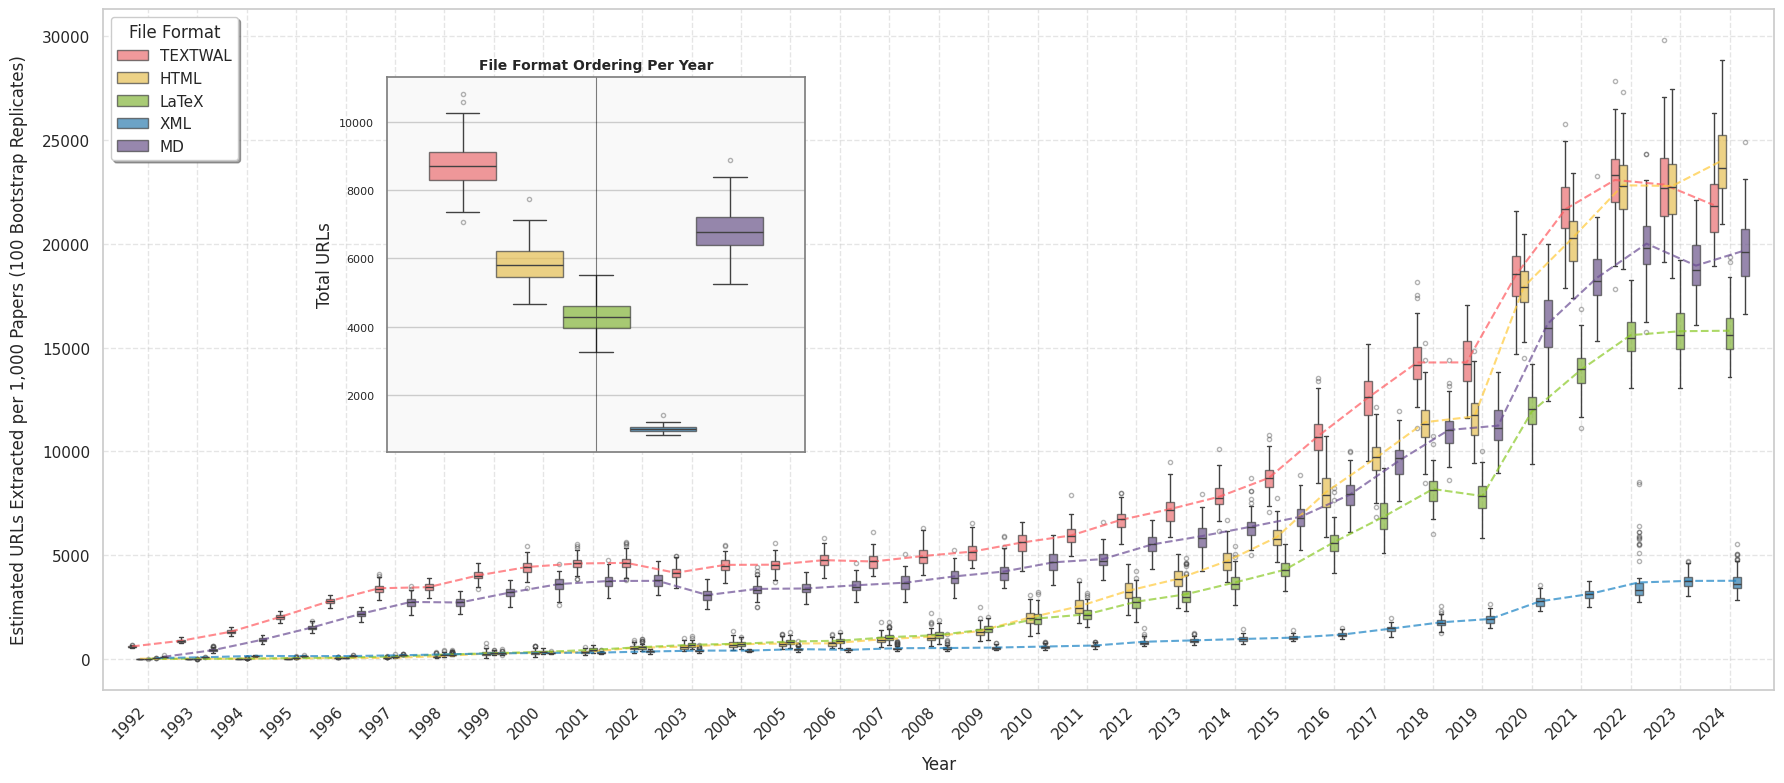

In [3]:
# %matplotlib inline
import json
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# Added a default seed parameter for reproducibility
def generate_bootstrap_boxplot(seed=42):
    # Lock in the random state
    random.seed(seed)
    print(f"Random seed set to: {seed}")

    # 1. Setup Data Extraction
    file_path = Path("data/la_360k_sample/arxiv_extracted_urls_5_formats_360k.json")

    print(f"Loading master JSON from {file_path}...")
    try:
        with open(file_path, 'r') as f:
            data = json.load(f)
    except FileNotFoundError:
        print(f"Error: Could not find {file_path}")
        return

    data_list = []
    
    SAMPLE_SIZE = 1000
    NUM_SAMPLES = 100 

    format_mapping = {
        "textwal": "TEXTWAL",
        "html": "HTML",
        "latex": "LaTeX",
        "xml": "XML",
        "markdown": "MD"
    }
    formats_order = ["TEXTWAL", "HTML", "LaTeX", "XML", "MD"]

    print("Extracting, sampling (with replacement), and aggregating data...")
    for year, ids_dict in data.items():
        year_ids = list(ids_dict.keys())
        
        if not year_ids:
            continue
        
        for sample_idx in range(NUM_SAMPLES):
            # Because the random seed is fixed, random.choices will pull 
            # the exact same sequence of papers on every run.
            selected_ids = random.choices(year_ids, k=SAMPLE_SIZE)
            
            sample_totals = {fmt_key: 0 for fmt_key in format_mapping.keys()}
            
            for arxiv_id in selected_ids:
                formats_data = ids_dict[arxiv_id]
                for fmt_key in format_mapping.keys():
                    if fmt_key in formats_data:
                        sample_totals[fmt_key] += formats_data[fmt_key].get("num_urls", 0)
            
            for fmt_key, total_urls in sample_totals.items():
                data_list.append({
                    "Year": int(year), 
                    "Format": format_mapping[fmt_key], 
                    "Total URLs per Sample": total_urls
                })

    df = pd.DataFrame(data_list)
    df = df.sort_values(by="Year")
    unique_years = df["Year"].unique()

    print(f"Creating plot with {len(df)} total aggregated data points...")

    custom_palette =  ["#FF595E", "#FFCA3A", "#8AC926", "#1982C4", "#6A4C93"]

    # 2. Plotting Configuration
    fig, ax = plt.subplots(figsize=(18, 8))
    sns.set_theme(style="whitegrid")

    sns.boxplot(
        data=df,
        x="Year",
        y="Total URLs per Sample",
        hue="Format",
        hue_order=formats_order,
        palette=custom_palette, 
        ax=ax,
        boxprops={"alpha": 0.7}, 
        meanprops={
            "markerfacecolor": "white",
            "markeredgecolor": "black",
            "markersize": 5,
        },
        flierprops={"marker": "o", "markersize": 3, "alpha": 0.4},
        width=0.8,
    )

    pad = 0.9  # 0.5 to 1.2 
    ax.set_xlim(-pad, len(unique_years) - 1 + pad)
    
    # 3. Add Trend Lines for each format
    mean_df = df.groupby(["Year", "Format"])["Total URLs per Sample"].mean().reset_index()

    colors = custom_palette 
    x_indices = np.arange(len(unique_years))

    for i, fmt in enumerate(formats_order):
        fmt_means_series = mean_df[mean_df["Format"] == fmt].set_index("Year")
        fmt_means = fmt_means_series.reindex(unique_years)["Total URLs per Sample"].values

        box_width = 0.8 / len(formats_order)
        shift = (i - (len(formats_order) - 1) / 2) * box_width

        ax.plot(
            x_indices + shift,
            fmt_means,
            linestyle="--",
            color=colors[i],
            alpha=0.7,
            linewidth=1.5,
        )

    # ---------------------------------------------------------
    # Add the Explanatory Inset Plot for a Single Year
    # ---------------------------------------------------------
    zoom_year = 2015
    
    if zoom_year in unique_years:
        # Create inset
        # Define inset position: [x0, y0, width, height] as fractions of the main axes
        # [0.03, 0.55, 0.25, 0.35] puts it in the upper-left corner
        ax_inset = ax.inset_axes([0.17, 0.35, 0.25, 0.55])
        
        df_zoom = df[df["Year"] == zoom_year]
        
        sns.boxplot(
            data=df_zoom,
            # x="Year",
            y="Total URLs per Sample",
            hue="Format",
            hue_order=formats_order,
            palette=custom_palette, 
            ax=ax_inset,
            boxprops={"alpha": 0.7},
            meanprops={"markerfacecolor": "white", "markeredgecolor": "black", "markersize": 4},
            flierprops={"marker": "o", "markersize": 3, "alpha": 0.4},
            width=0.8,
        )

        ax_inset.axvline(x=0, color='black', linestyle='-', linewidth=0.8, alpha=0.5)
        
        # Formatting
        ax_inset.set_title(f"File Format Ordering Per Year", fontsize=10, weight="bold")
        ax_inset.set_ylabel("Total URLs")
        ax_inset.tick_params(axis='y', labelsize=8)
        
        if ax_inset.get_legend() is not None:
            ax_inset.get_legend().remove()
            
        ax_inset.set_facecolor("#f9f9f9")
        for spine in ax_inset.spines.values():
            spine.set_edgecolor('gray')
            

    ax.set_xlabel("Year", fontsize=12, labelpad=10)
    ax.set_ylabel("Estimated URLs Extracted per 1,000 Papers (100 Bootstrap Replicates)", fontsize=12, labelpad=10)
    # ax.set_ylabel("Total URLs (Sum of 1000 Bootstrapped Papers)", fontsize=12, labelpad=10)

    ax.set_xticks(x_indices)
    ax.set_xticklabels(unique_years, rotation=45, ha="right")
    ax.grid(True, linestyle="--", alpha=0.5)

    ax.legend(title="File Format", loc="upper left", frameon=True, shadow=True)

    plt.tight_layout()
    
    # 5. Output
    output_filename = "url_longitudinal_boxplot_100_replicates.pdf"
    plt.savefig(output_filename, format="pdf")
    print(f"Success! Graph saved as {output_filename}")

if __name__ == "__main__":
    generate_bootstrap_boxplot(seed=42)